In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load feature engineered dataset
df = pd.read_csv(r'C:\BFSI_Loan_Analytics\data\processed\lending_club_features.csv', low_memory=False)

print("Shape:", df.shape)
print("Nulls:", df.isnull().sum().sum())

Shape: (1342942, 91)
Nulls: 0


  grade  default_rate  loan_count  default_rate_pct
0     A      0.059746      234912              5.97
1     B      0.132957      392322             13.30
2     C      0.223172      381070             22.32
3     D      0.301921      200397             30.19
4     E      0.382343       93275             38.23
5     F      0.449549       31912             44.95
6     G      0.495030        9054             49.50


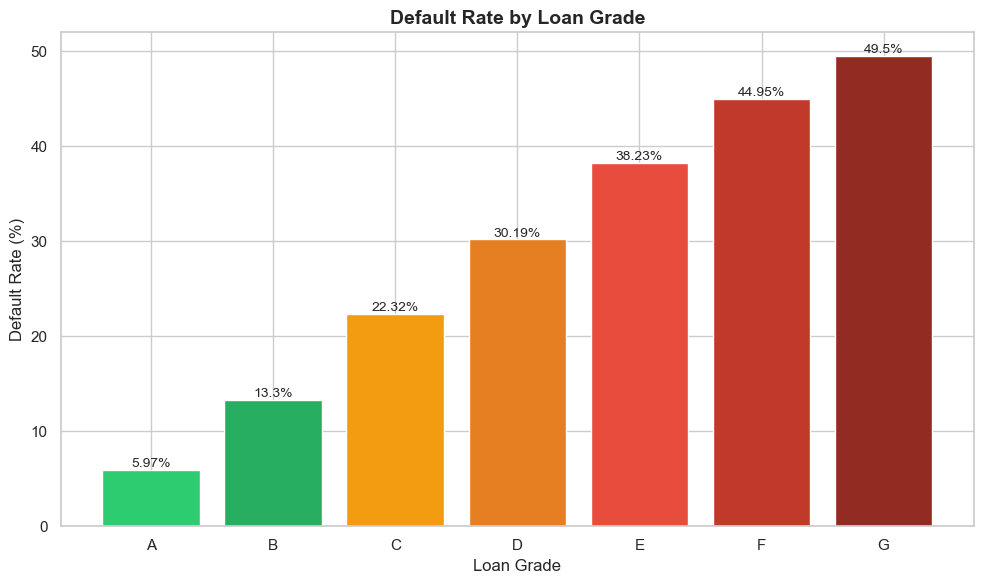

Chart saved.


In [2]:
# Calculate default rate by grade
grade_default = df.groupby('grade')['loan_outcome'].agg(['mean', 'count']).reset_index()
grade_default.columns = ['grade', 'default_rate', 'loan_count']
grade_default['default_rate_pct'] = (grade_default['default_rate'] * 100).round(2)

print(grade_default.to_string())

# Plot
fig, ax = plt.subplots()
bars = ax.bar(grade_default['grade'], grade_default['default_rate_pct'],
              color=['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#922b21'])

ax.set_title('Default Rate by Loan Grade', fontsize=14, fontweight='bold')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Default Rate (%)')

# Add value labels on bars
for bar, val in zip(bars, grade_default['default_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\BFSI_Loan_Analytics\assets\screenshots\01_default_rate_by_grade.png', dpi=150)
plt.show()
print("Chart saved.")

In [3]:
# Check Grade E-G portfolio share vs default contribution
total_loans = len(df)
total_defaults = df['loan_outcome'].sum()

eg_loans = df[df['grade'].isin(['E', 'F', 'G'])]
eg_defaults = eg_loans['loan_outcome'].sum()

print(f"Total loans: {total_loans:,}")
print(f"Total defaults: {total_defaults:,}")
print(f"\nGrade E-G loan count: {len(eg_loans):,}")
print(f"Grade E-G portfolio share: {len(eg_loans)/total_loans*100:.1f}%")
print(f"\nGrade E-G defaults: {eg_defaults:,}")
print(f"Grade E-G share of ALL defaults: {eg_defaults/total_defaults*100:.1f}%")

Total loans: 1,342,942
Total defaults: 266,236

Grade E-G loan count: 134,241
Grade E-G portfolio share: 10.0%

Grade E-G defaults: 54,491
Grade E-G share of ALL defaults: 20.5%


  RiskTier  default_rate  loan_count  default_rate_pct
1      Low      0.105538      627234             10.55
2   Medium      0.250312      581467             25.03
0     High      0.405919      134241             40.59


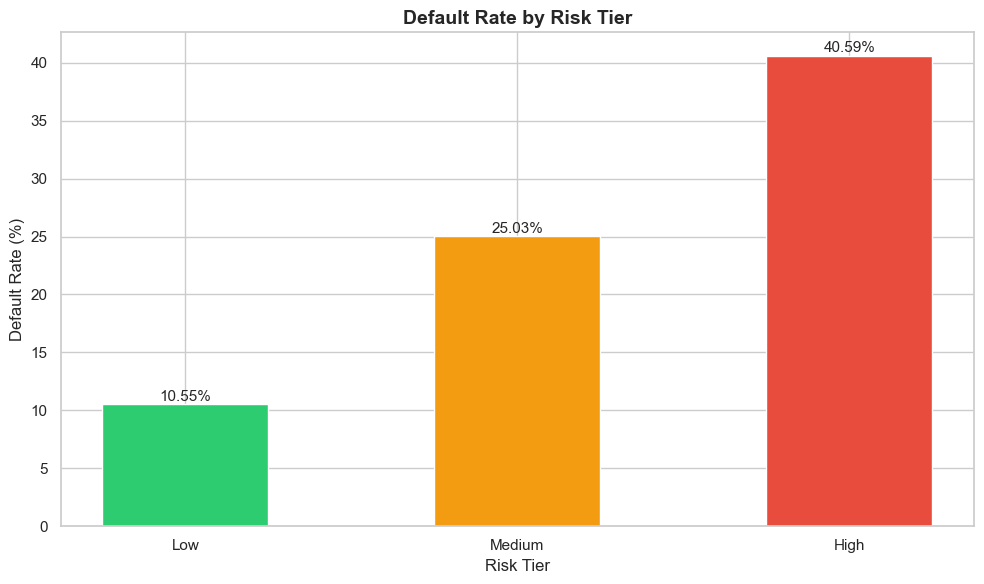

Chart saved.


In [4]:
# Default rate by Risk Tier
risk_default = df.groupby('RiskTier')['loan_outcome'].agg(['mean', 'count']).reset_index()
risk_default.columns = ['RiskTier', 'default_rate', 'loan_count']
risk_default['default_rate_pct'] = (risk_default['default_rate'] * 100).round(2)

# Order tiers correctly
risk_default['RiskTier'] = pd.Categorical(risk_default['RiskTier'], categories=['Low', 'Medium', 'High'], ordered=True)
risk_default = risk_default.sort_values('RiskTier')

print(risk_default.to_string())

# Plot
fig, ax = plt.subplots()
bars = ax.bar(risk_default['RiskTier'], risk_default['default_rate_pct'],
              color=['#2ecc71', '#f39c12', '#e74c3c'], width=0.5)

ax.set_title('Default Rate by Risk Tier', fontsize=14, fontweight='bold')
ax.set_xlabel('Risk Tier')
ax.set_ylabel('Default Rate (%)')

for bar, val in zip(bars, risk_default['default_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(r'C:\BFSI_Loan_Analytics\assets\screenshots\02_default_rate_by_risk_tier.png', dpi=150)
plt.show()
print("Chart saved.")

  DTIBand  default_rate  loan_count  default_rate_pct
0    0-10      0.146557      245516             14.66
1   10-15      0.164675      272719             16.47
2   15-20      0.189144      288922             18.91
3   20-25      0.216363      240633             21.64
4     25+      0.266412      295152             26.64


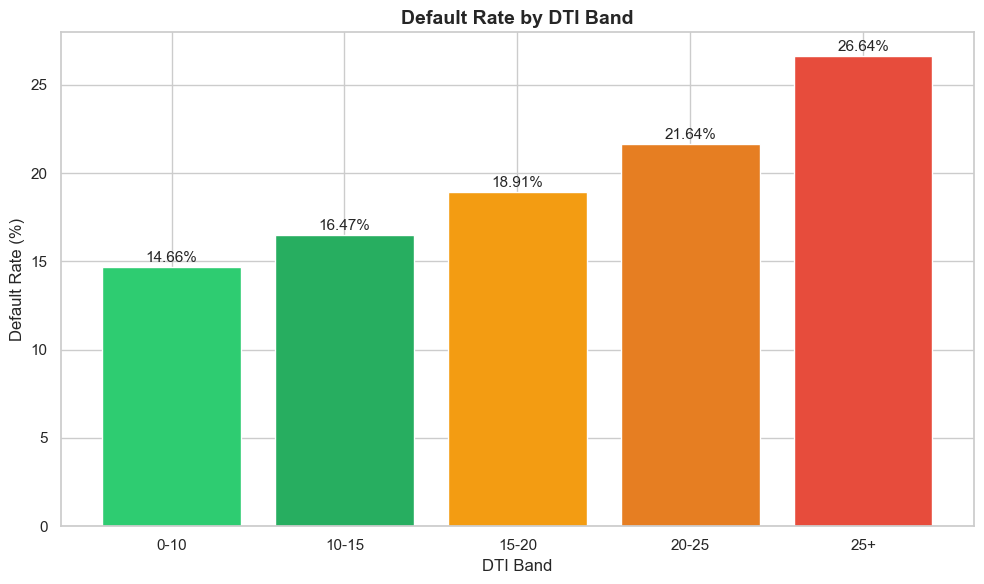

Chart saved.


In [5]:
# Default rate by DTI Band
dti_default = df.groupby('DTIBand', observed=True)['loan_outcome'].agg(['mean', 'count']).reset_index()
dti_default.columns = ['DTIBand', 'default_rate', 'loan_count']
dti_default['default_rate_pct'] = (dti_default['default_rate'] * 100).round(2)

print(dti_default.to_string())

# Plot
fig, ax = plt.subplots()
bars = ax.bar(dti_default['DTIBand'], dti_default['default_rate_pct'],
              color=['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c'])

ax.set_title('Default Rate by DTI Band', fontsize=14, fontweight='bold')
ax.set_xlabel('DTI Band')
ax.set_ylabel('Default Rate (%)')

for bar, val in zip(bars, dti_default['default_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(r'C:\BFSI_Loan_Analytics\assets\screenshots\03_default_rate_by_dti_band.png', dpi=150)
plt.show()
print("Chart saved.")

  IncomeBand  default_rate  loan_count  default_rate_pct
1        Low      0.231072      335744             23.11
2     Medium      0.210133      361590             21.01
0       High      0.189648      311994             18.96
3  Very High      0.160377      333614             16.04


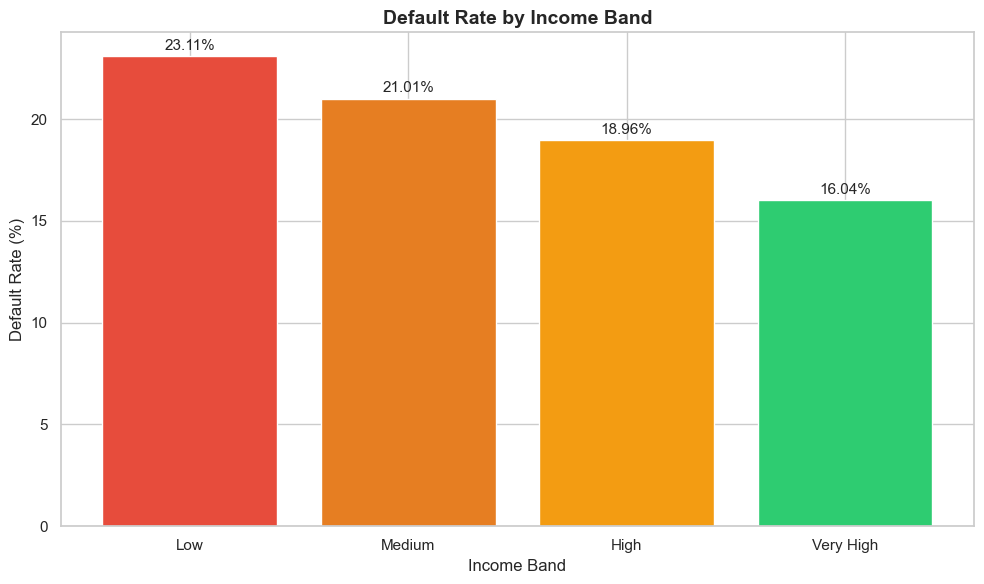

Chart saved.


In [6]:
# Default rate by Income Band
income_default = df.groupby('IncomeBand', observed=True)['loan_outcome'].agg(['mean', 'count']).reset_index()
income_default.columns = ['IncomeBand', 'default_rate', 'loan_count']
income_default['default_rate_pct'] = (income_default['default_rate'] * 100).round(2)

# Order correctly
income_default['IncomeBand'] = pd.Categorical(income_default['IncomeBand'], 
                                               categories=['Low', 'Medium', 'High', 'Very High'], 
                                               ordered=True)
income_default = income_default.sort_values('IncomeBand')

print(income_default.to_string())

# Plot
fig, ax = plt.subplots()
bars = ax.bar(income_default['IncomeBand'], income_default['default_rate_pct'],
              color=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71'])

ax.set_title('Default Rate by Income Band', fontsize=14, fontweight='bold')
ax.set_xlabel('Income Band')
ax.set_ylabel('Default Rate (%)')

for bar, val in zip(bars, income_default['default_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(r'C:\BFSI_Loan_Analytics\assets\screenshots\04_default_rate_by_income_band.png', dpi=150)
plt.show()
print("Chart saved.")

               purpose  default_rate  loan_count  default_rate_pct
11      small_business      0.294302       15355             29.43
8               moving      0.230215        9439             23.02
10    renewable_energy      0.226927         921             22.69
5                house      0.215265        7219             21.53
7              medical      0.212811       15455             21.28
2   debt_consolidation      0.210401      779228             21.04
9                other      0.207034       77543             20.70
12            vacation      0.189760        9043             18.98
6       major_purchase      0.182281       29290             18.23
4     home_improvement      0.174936       87266             17.49
1          credit_card      0.168605      295033             16.86
3          educational      0.164087         323             16.41
0                  car      0.144645       14546             14.46
13             wedding      0.116616        2281             1

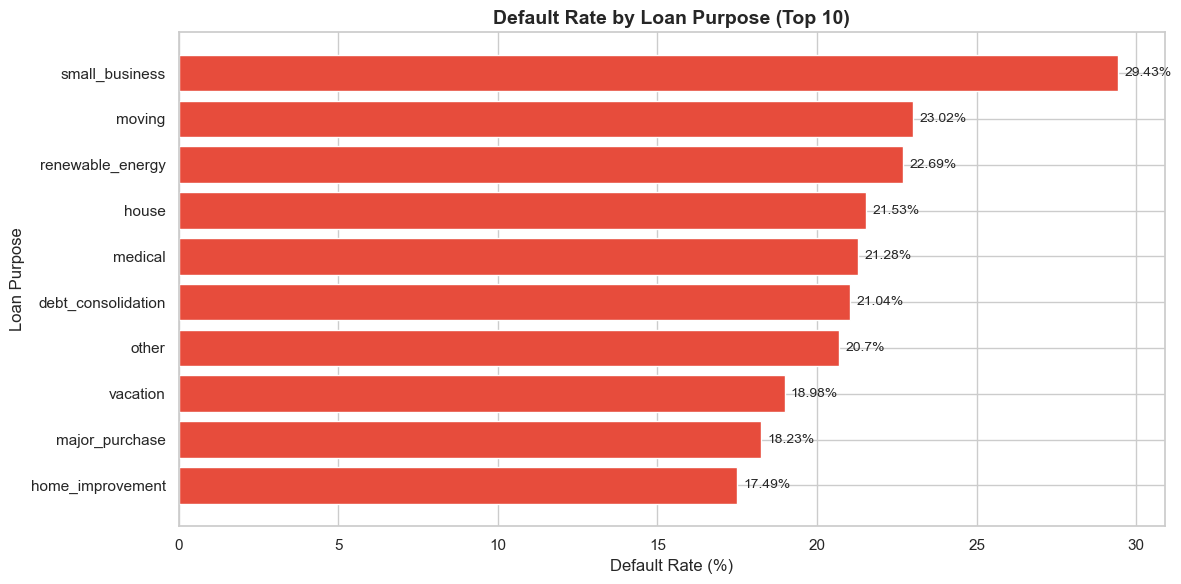

Chart saved.


In [7]:
# Default rate by loan purpose
purpose_default = df.groupby('purpose')['loan_outcome'].agg(['mean', 'count']).reset_index()
purpose_default.columns = ['purpose', 'default_rate', 'loan_count']
purpose_default['default_rate_pct'] = (purpose_default['default_rate'] * 100).round(2)
purpose_default = purpose_default.sort_values('default_rate_pct', ascending=False)

print(purpose_default.to_string())

# Plot top 10
top10 = purpose_default.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top10['purpose'], top10['default_rate_pct'], color='#e74c3c')

ax.set_title('Default Rate by Loan Purpose (Top 10)', fontsize=14, fontweight='bold')
ax.set_xlabel('Default Rate (%)')
ax.set_ylabel('Loan Purpose')
ax.invert_yaxis()

for bar, val in zip(bars, top10['default_rate_pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\BFSI_Loan_Analytics\assets\screenshots\05_default_rate_by_purpose.png', dpi=150)
plt.show()
print("Chart saved.")

    year  default_rate  loan_count  default_rate_pct
0   2007      0.180000         250             18.00
1   2008      0.157591        1561             15.76
2   2009      0.123724        4704             12.37
3   2010      0.127312       11515             12.73
4   2011      0.150302       21683             15.03
5   2012      0.161030       53307             16.10
6   2013      0.155400      134704             15.54
7   2014      0.183968      222935             18.40
8   2015      0.201224      375244             20.12
9   2016      0.231479      292571             23.15
10  2017      0.228498      168697             22.85
11  2018      0.149343       55771             14.93


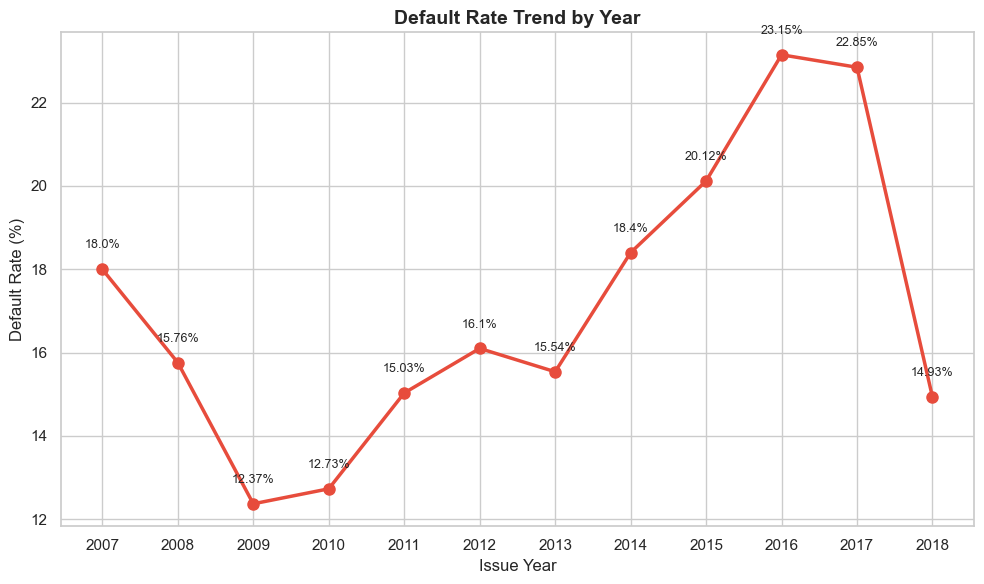

Chart saved.


In [8]:
# Extract year from issue_d
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['issue_year'] = df['issue_d'].dt.year

# Default rate by year
year_default = df.groupby('issue_year')['loan_outcome'].agg(['mean', 'count']).reset_index()
year_default.columns = ['year', 'default_rate', 'loan_count']
year_default['default_rate_pct'] = (year_default['default_rate'] * 100).round(2)

print(year_default.to_string())

# Plot
fig, ax = plt.subplots()
ax.plot(year_default['year'], year_default['default_rate_pct'], 
        marker='o', linewidth=2.5, color='#e74c3c', markersize=8)

ax.set_title('Default Rate Trend by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Issue Year')
ax.set_ylabel('Default Rate (%)')
ax.set_xticks(year_default['year'])

for x, y in zip(year_default['year'], year_default['default_rate_pct']):
    ax.text(x, y + 0.5, f'{y}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(r'C:\BFSI_Loan_Analytics\assets\screenshots\06_default_rate_by_year.png', dpi=150)
plt.show()
print("Chart saved.")

In [9]:
# Print full EDA summary
print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 55)
print(f"Total loans analysed: 1,342,942")
print(f"Overall default rate: 19.82%")
print(f"\nBy Grade:")
print(f"  Grade A: 5.97% | Grade G: 49.50%")
print(f"\nBy Risk Tier:")
print(f"  Low: 10.55% | Medium: 25.03% | High: 40.59%")
print(f"  High risk defaults at 3.8x rate of Low risk")
print(f"\nBy DTI Band:")
print(f"  DTI 0-10: 14.66% | DTI 25+: 26.64%")
print(f"  DTI 25+ defaults at 1.82x rate of DTI 0-10")
print(f"\nBy Income Band:")
print(f"  Low income: 23.11% | Very High income: 16.04%")
print(f"\nBy Purpose:")
print(f"  Highest: Small Business 29.43%")
print(f"  Lowest: Wedding 11.66%")
print(f"\nBy Year:")
print(f"  Peak: 2016 at 23.15%")
print(f"  2018 low (14.93%) may reflect loan maturity lag")

EDA SUMMARY — KEY FINDINGS
Total loans analysed: 1,342,942
Overall default rate: 19.82%

By Grade:
  Grade A: 5.97% | Grade G: 49.50%

By Risk Tier:
  Low: 10.55% | Medium: 25.03% | High: 40.59%
  High risk defaults at 3.8x rate of Low risk

By DTI Band:
  DTI 0-10: 14.66% | DTI 25+: 26.64%
  DTI 25+ defaults at 1.82x rate of DTI 0-10

By Income Band:
  Low income: 23.11% | Very High income: 16.04%

By Purpose:
  Highest: Small Business 29.43%
  Lowest: Wedding 11.66%

By Year:
  Peak: 2016 at 23.15%
  2018 low (14.93%) may reflect loan maturity lag
